In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from src.utils import compute_individual_expectation_values, build_hva_layers, build_sparse_hamiltonian,find_best_initial_params,test_energy_consistency,optimize_energy, compute_error

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2, FakeAthensV2

from matplotlib import pyplot as plt
import sys
import numpy as np
from qiskit.quantum_info import Pauli, Statevector
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_gate_map
from qiskit.transpiler import CouplingMap

import pickle
import pandas as pd
import dill
"""with open("WS_TestFramework_realBackend.dill", "rb") as f:
    globals().update(dill.load(f))"""

sys.path.append("../../pauli_lindblad_per/")
from tomography.experiment import SparsePauliTomographyExperiment as tomography

plt.style.use("ggplot")

Initial Error        : 0.10484684299231528
Exakte Energie       :  -7.819890870294845
Startparameter       : [ 0.         -1.57079633  1.57079633]
Optimierte Parameter : [-2.41316809e-05 -1.96807401e+00  1.57081561e+00]
Minimaler Fehler     : 0.004204533085092007


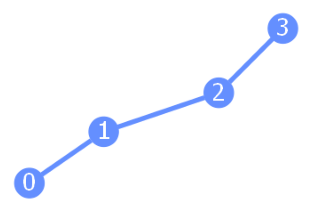

In [2]:
# Lineare Kopplung: 0–1–2–3
coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (2, 3)])
backend = GenericBackendV2(num_qubits=4, coupling_map=coupling)

plot_gate_map(backend)

hx = 1
hz = 1
J=-1
H_sparse = build_sparse_hamiltonian(hx, hz, backend, J=J)

best_guess, energy_exact = find_best_initial_params(H_sparse, backend)

opt_params, min_error = optimize_energy(best_guess, H_sparse, backend, energy_exact)

print(f"Initial Error        : {compute_error(best_guess, H_sparse, backend, energy_exact, num_layers=1)}")
print("Exakte Energie       : ", energy_exact)
print("Startparameter       :",best_guess)
print("Optimierte Parameter :", opt_params)
print("Minimaler Fehler     :", min_error)

In [3]:
expectation_values, paulis = compute_individual_expectation_values(opt_params, backend, hx, hz,J=J, num_layers=1)
pauli_list = paulis
print(pauli_list)

['IIZZ', 'IZZI', 'ZZII', 'IIIX', 'IIIZ', 'IIXI', 'IIZI', 'IXII', 'IZII', 'XIII', 'ZIII']


In [4]:
df = pd.DataFrame({
    'Pauli': paulis,
    'Expectation Value': expectation_values
})
df

,Pauli,Expectation Value
0,IIZZ,0.850301
1,IZZI,0.850301
2,ZZII,0.850301
3,IIIX,-0.386909
4,IIIZ,-0.922118
5,IIXI,-0.386909
6,IIZI,-0.922118
7,IXII,-0.386909
8,IZII,-0.922118
9,XIII,-0.386909


In [5]:
inst_map = [0,1,2,3]
qc = build_hva_layers(opt_params, backend, num_layers=1)

qc.draw(fold=-1)

┌───┐                             ┌─────────────┐   ┌────────────┐                                                                           
q_0: ┤ H ├──■───────────────────────■──┤ Rz(-1.9681) ├───┤ Rx(1.5708) ├───────────────────────────────────────────────────────────────────────────
     ├───┤┌─┴─┐┌─────────────────┐┌─┴─┐└─────────────┘   └────────────┘       ┌─────────────┐   ┌────────────┐                                    
q_1: ┤ H ├┤ X ├┤ Rz(-2.4132e-05) ├┤ X ├───────■────────────────────────────■──┤ Rz(-1.9681) ├───┤ Rx(1.5708) ├────────────────────────────────────
     ├───┤└───┘└─────────────────┘└───┘     ┌─┴─┐     ┌─────────────────┐┌─┴─┐└─────────────┘   └────────────┘       ┌─────────────┐┌────────────┐
q_2: ┤ H ├──────────────────────────────────┤ X ├─────┤ Rz(-2.4132e-05) ├┤ X ├───────■────────────────────────────■──┤ Rz(-1.9681) ├┤ Rx(1.5708) ├
     ├───┤                                  └───┘     └─────────────────┘└───┘     ┌─┴─┐     ┌─────────────────┐┌─┴─┐├─────────────┤├────────────┤
q_3: ┤ H ├─────────────────────────────────────────────────────────────────────────┤ X ├─────┤ Rz(-2.4132e-05) ├┤ X ├┤ Rz(-1.9681) ├┤ Rx(1.5708) ├
     └───┘                                                                         └───┘     └─────────────────┘└───┘└─────────────┘└────────────┘

In [6]:
# --- 5. Simulator instanziieren ---
backend = FakeWashingtonV2()
noise_model = NoiseModel.from_backend(backend)
simulator = AerSimulator(noise_model=noise_model)


In [7]:
experiment = tomography(
    circuits = [qc], #list of circuits from which to get the layers requiring tomography
    inst_map = inst_map, #which physical qubits on the processor to map the qubits in the circuit
    backend = backend, #quantum backend
    used_qubits= inst_map
    )

experiment.generate(
    samples = 100, #Number of samples to take from the fidelity pair measurements
    single_samples = 250, #samples to take from the pair-breaking measurements
    depths = [2,4,16,32,64] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

shots = 1024
def executor(circuits):
    return backend.run(circuits, shots = shots, noise_model=noise_model).result().get_counts()

#run the experiment
experiment.run(executor)
noisedataframe = experiment.analyze()

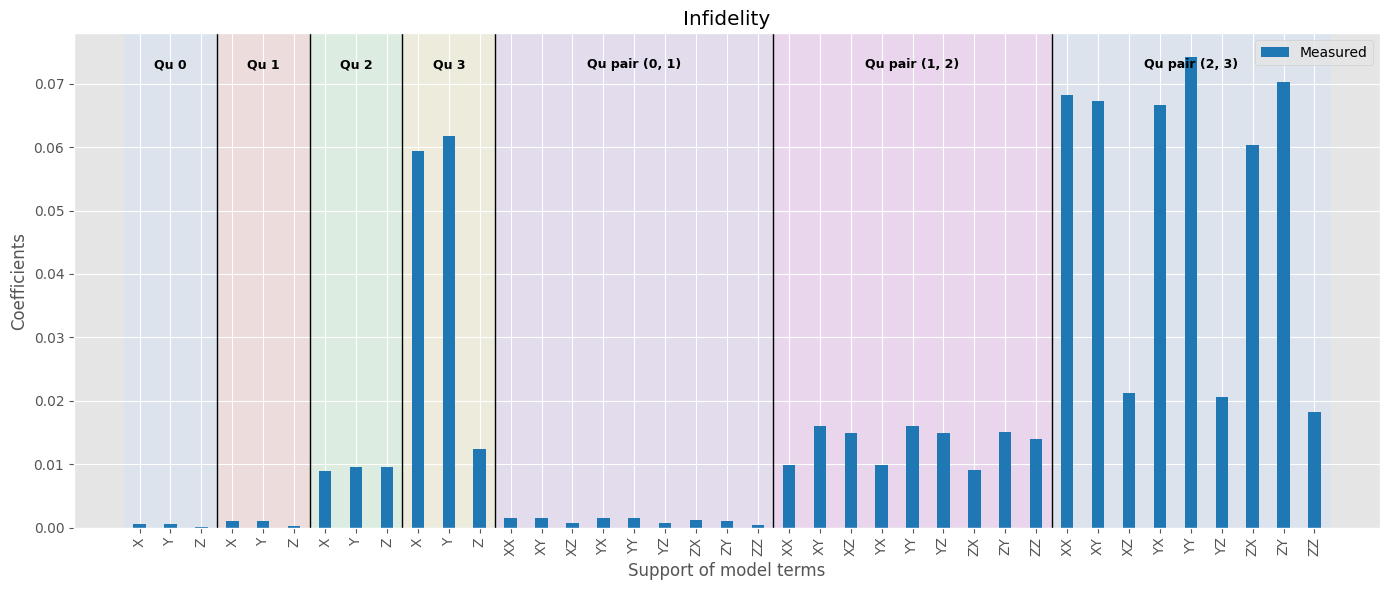

In [8]:
layer1 = experiment.analysis.get_layer_data(0)
layer1.plot_infidelitites(plot_style = 2)

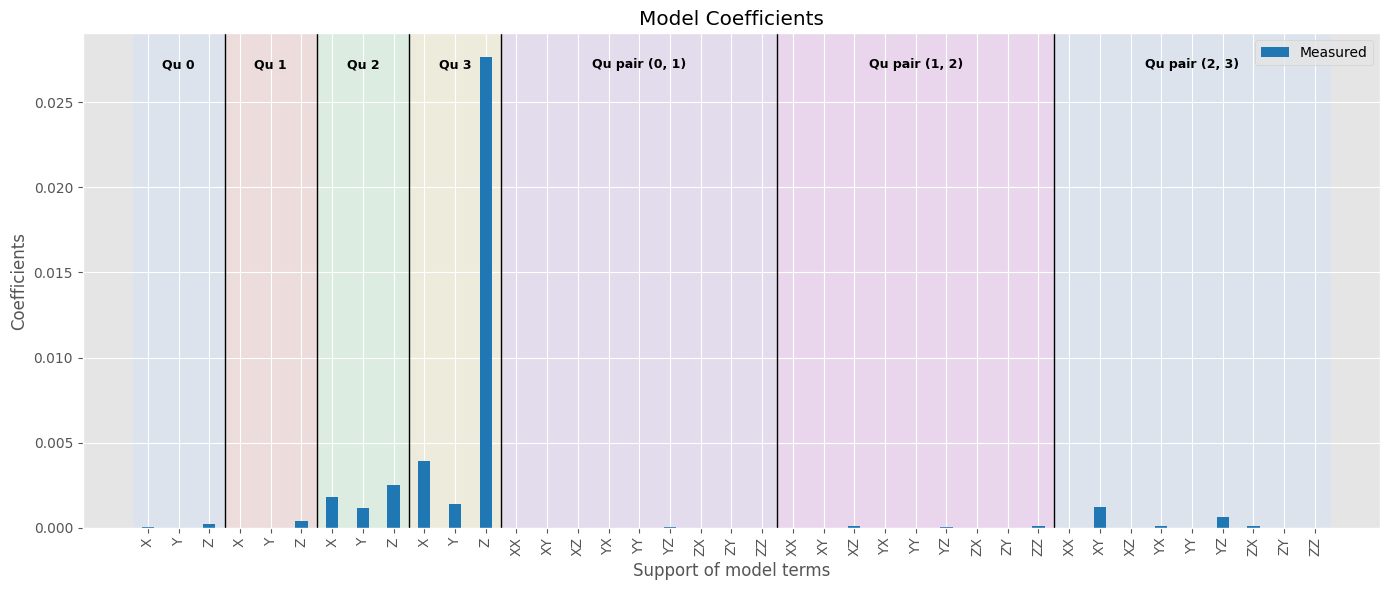

In [9]:
layer1.plot_coeffs(plot_style = 2)

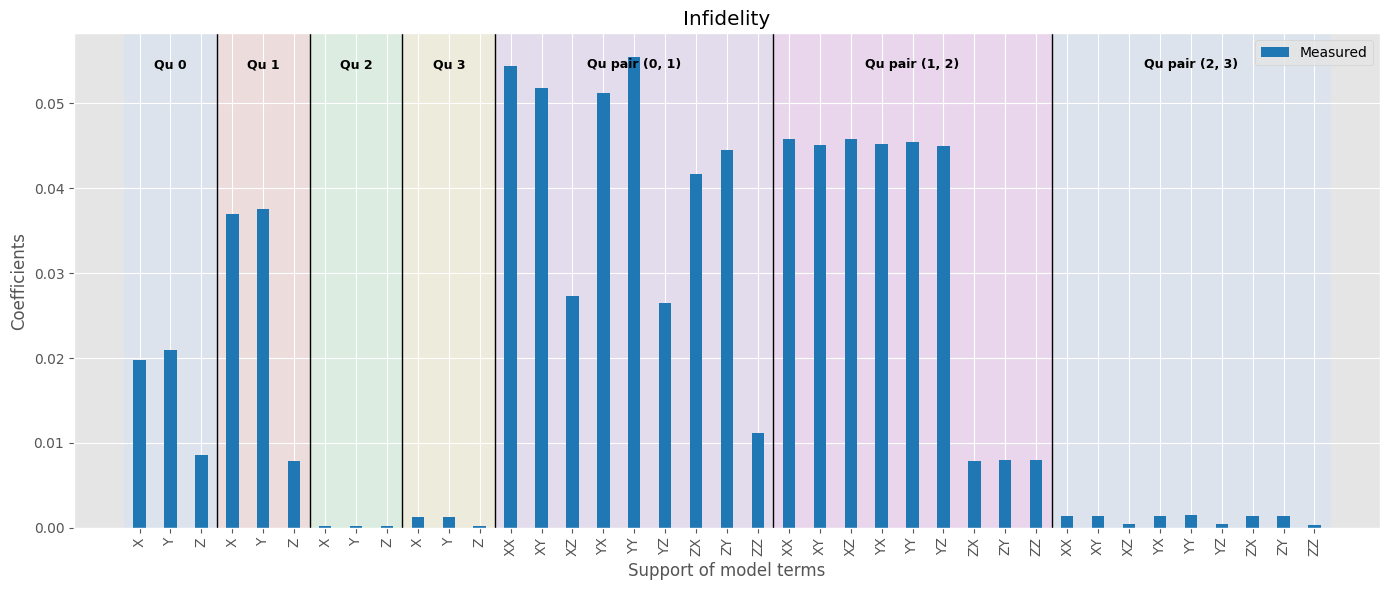

In [10]:
layer2 = experiment.analysis.get_layer_data(1)
layer2.plot_infidelitites(plot_style = 2)

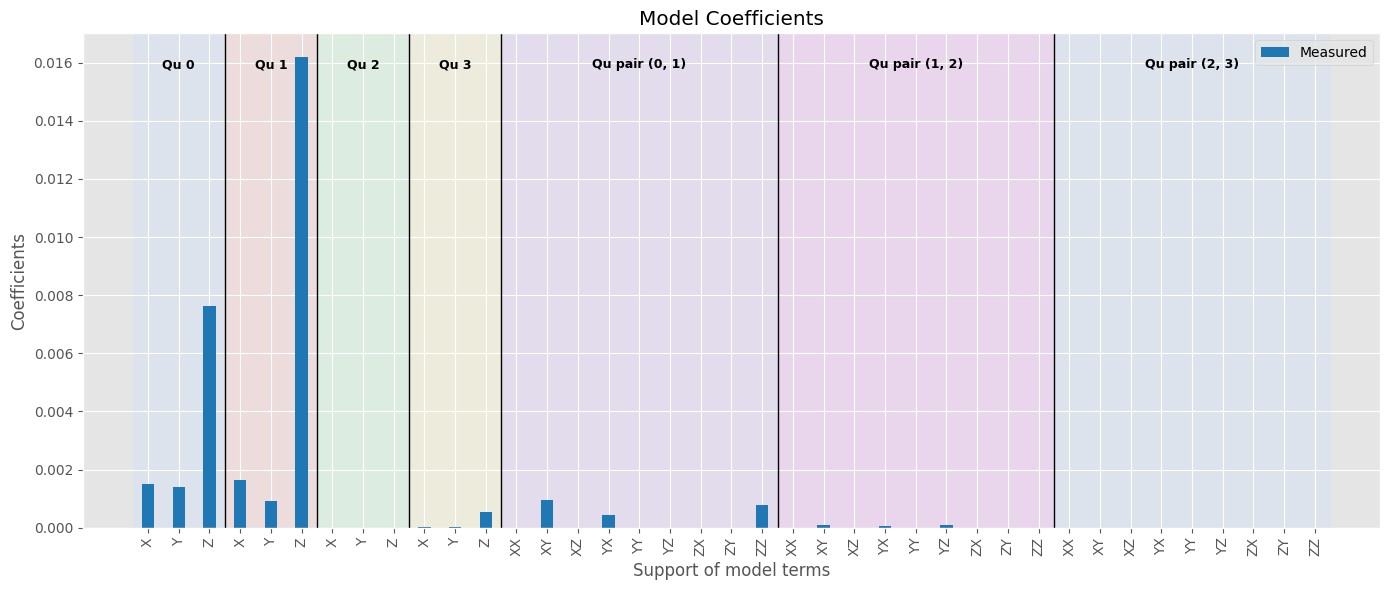

In [11]:
layer2.plot_coeffs(plot_style = 2)

In [12]:
# 2. PER-Experiment Setup
perexp = experiment.create_per_experiment([qc])

perexp.generate(
    expectations=pauli_list,
    samples=1000,
    noise_strengths=[0, 1, 2]
)

# 3. Ausführen
perexp.run(executor)

Aus SV-Simulation:  0.8503010480918998


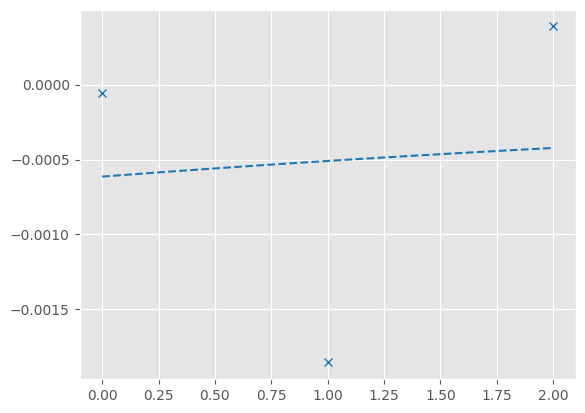

In [13]:
# 4. Analysieren
per_results = perexp.analyze()
result_1 = per_results[0].get_result(pauli_list[2]).plot()
print("Aus SV-Simulation: ",expectation_values[1])

In [14]:
# Compare absolute vs relative errors
for k in range(len(pauli_list)):
    exact = expectation_values[k]
    calc = per_results[0].get_result(pauli_list[k]).get_expectations()[0]
    abs_error = abs(exact - calc)
    rel_error = abs_error / abs(exact) if exact != 0 else float('inf')
    
    print(f"{pauli_list[k]}: Exact={exact:.4f}, Calc={calc:.4f}")
    print(f"  Absolute error: {abs_error:.6f}")
    print(f"  Relative error: {rel_error*100:.2f}%")
    print()

IIZZ: Exact=0.8503, Calc=0.8344
  Absolute error: 0.015949
  Relative error: 1.88%

IZZI: Exact=0.8503, Calc=0.0014
  Absolute error: 0.848949
  Relative error: 99.84%

ZZII: Exact=0.8503, Calc=-0.0001
  Absolute error: 0.850357
  Relative error: 100.01%

IIIX: Exact=-0.3869, Calc=-0.3859
  Absolute error: 0.000995
  Relative error: 0.26%

IIIZ: Exact=-0.9221, Calc=-0.9214
  Absolute error: 0.000690
  Relative error: 0.07%

IIXI: Exact=-0.3869, Calc=-0.3817
  Absolute error: 0.005181
  Relative error: 1.34%

IIZI: Exact=-0.9221, Calc=-0.9129
  Absolute error: 0.009202
  Relative error: 1.00%

IXII: Exact=-0.3869, Calc=1.0036
  Absolute error: 1.390542
  Relative error: 359.40%

IZII: Exact=-0.9221, Calc=-0.0022
  Absolute error: 0.919908
  Relative error: 99.76%

XIII: Exact=-0.3869, Calc=1.0016
  Absolute error: 1.388548
  Relative error: 358.88%

ZIII: Exact=-0.9221, Calc=-0.0014
  Absolute error: 0.920752
  Relative error: 99.85%



In [15]:
import dill

to_save = {
    'experiment': experiment,
    'noisedataframe': noisedataframe,
    'expectation_values': expectation_values,
    'backend': backend,
    'simulator': simulator,
    'pauli_list': pauli_list,
    'perexp': perexp
}

with open("WS_TestFramework_realNoisemodel.dill", "wb") as f:
    dill.dump(to_save, f)

KeyboardInterrupt: 